In [1]:
import pandas as pd
import numpy as np
import json
import ast

In [3]:
movies=pd.read_csv('/content/drive/MyDrive/Archivos .csv/movies_metadata.csv')
creditos=pd.read_csv('/content/drive/MyDrive/Archivos .csv/credits.csv')

/tmp/ipython-input-269344844.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies=pd.read_csv('/content/drive/MyDrive/Archivos .csv/movies_metadata.csv')


In [4]:
# Limpieza de IDs y Tipos de Datos
# Corregir la columna 'id' en movies_metadata (contiene valores no numéricos)
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies = movies.dropna(subset=['id'])
movies['id'] = movies['id'].astype(int)
creditos['id'] = creditos['id'].astype(int)

# Limpieza y preparación de columnas clave
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce').fillna(0)
movies['vote_count'] = pd.to_numeric(movies['vote_count'], errors='coerce').fillna(0)
movies['vote_average'] = pd.to_numeric(movies['vote_average'], errors='coerce').fillna(0)

# Fusión
df = pd.merge(movies, creditos, on='id', how='inner')

# Eliminamos 'revenue' como pide el enunciado
df = df.drop(columns=['revenue'], errors='ignore')

print(f"Dimensiones del dataset final después de la fusión: {df.shape}")

Dimensiones del dataset final después de la fusión: (45538, 25)


In [5]:
# Constantes para la fórmula
m = df['vote_average'].mean() # Media de la puntuación (m)
C = df['vote_count'].median() # Mediana del número de votos (C)

# Función para calcular la media bayesiana
def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + C) * R) + (C / (v + C) * m)

# Creamos la columna objetivo
df['bayesian_rating'] = df.apply(weighted_rating, axis=1)

In [6]:
# Funciones de Extracción

def get_list_names(json_string):
    """Extrae las listas de nombres (ej: géneros) de una columna JSON string."""
    try:
        data = ast.literal_eval(json_string)
        if isinstance(data, list):
            return [i['name'] for i in data]
    except:
        pass
    return []

def get_director(json_string):
    """Extrae el nombre del director de la columna 'crew'."""
    try:
        data = ast.literal_eval(json_string)
        if isinstance(data, list):
            for i in data:
                if i['job'] == 'Director':
                    return i['name']
    except:
        pass
    return np.nan

def get_top_cast(json_string, num=3):
    """Extrae los nombres de los primeros 'num' actores."""
    try:
        data = ast.literal_eval(json_string)
        if isinstance(data, list):
            return [i['name'] for i in data][:num]
    except:
        pass
    return []

# Aplicar Funciones
df['genres_list'] = df['genres'].apply(get_list_names)
df['director_name'] = df['crew'].apply(get_director)
df['cast_top3'] = df['cast'].apply(get_top_cast)

In [7]:
from sklearn.preprocessing import MultiLabelBinarizer

# Encoding de Géneros (MultiLabelBinarizer)
mlb = MultiLabelBinarizer()
genres_encoded = pd.DataFrame(mlb.fit_transform(df['genres_list']),
                              columns=mlb.classes_,
                              index=df.index)

# Encoding del Director (Agrupamos directores poco frecuentes en 'Other')
# Solo consideramos directores con más de 10 películas para OHE.
director_counts = df['director_name'].value_counts()
top_directors = director_counts[director_counts > 10].index

df['director_grouped'] = df['director_name'].apply(
    lambda x: x if x in top_directors else 'Other'
)
director_encoded = pd.get_dummies(df['director_grouped'], prefix='dir')

# Crear el DataFrame final para el modelo (X e y)
df_model = pd.concat([df[['budget', 'bayesian_rating']],
                      genres_encoded,
                      director_encoded], axis=1)

# Eliminamos filas con presupuestos muy bajos (ruido)
df_model = df_model[df_model['budget'] > 1000].copy()


--- Top 10 Correlaciones Positivas con Media Bayesiana (Target) ---
Drama                    0.262539
History                  0.120535
War                      0.106388
budget                   0.105787
Crime                    0.082720
Animation                0.081851
dir_Alfred Hitchcock     0.075140
dir_Martin Scorsese      0.071000
dir_Christopher Nolan    0.068206
dir_Steven Spielberg     0.063596
Name: bayesian_rating, dtype: float64

--- Top 5 Correlaciones Negativas con Media Bayesiana (Target) ---
dir_William Keighley   NaN
dir_William Lau        NaN
dir_Wong Jing          NaN
dir_Yasujirō Ozu       NaN
dir_Éric Rohmer        NaN
Name: bayesian_rating, dtype: float64


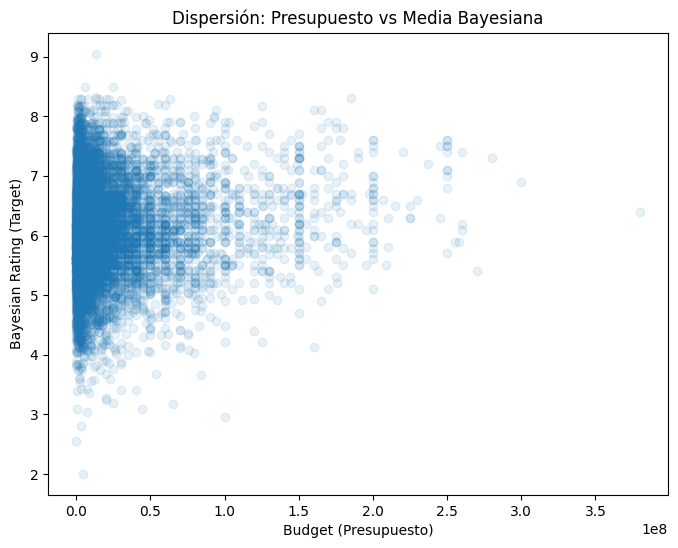

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlación del Target con las Features
correlations = df_model.corr()['bayesian_rating'].sort_values(ascending=False)
print("\n--- Top 10 Correlaciones Positivas con Media Bayesiana (Target) ---")
print(correlations.head(11).iloc[1:])

print("\n--- Top 5 Correlaciones Negativas con Media Bayesiana (Target) ---")
print(correlations.tail(5))

# Gráfico de dispersión para Budget vs Target (para ver si es lineal)
plt.figure(figsize=(8, 6))
plt.scatter(df_model['budget'], df_model['bayesian_rating'], alpha=0.1)
plt.xlabel('Budget (Presupuesto)')
plt.ylabel('Bayesian Rating (Target)')
plt.title('Dispersión: Presupuesto vs Media Bayesiana')
plt.show()


# Conclusión EDA:
# El gráfico de dispersión muestra una correlación positiva, pero dispersa, lo que sugiere que
# la relación con el presupuesto no es estrictamente lineal. Las correlaciones altas en ciertos
# géneros (e.g., Documental, Historia) indican que la categoría influye fuertemente en la
# calificación media bayesiana.

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

# Resetear el índice después del filtrado para evitar errores.
df_model = df_model.reset_index(drop=True)

# Crear categorías de presupuesto (5 tramos)
df_model['budget_cat'] = pd.cut(df_model['budget'],
                               bins=[0, 1e6, 10e6, 50e6, 100e6, np.inf],
                               labels=[1, 2, 3, 4, 5],
                               right=False)

# Inicializar el Splitter (80% Train, 20% Test)
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Generar los conjuntos Train y Test
for train_index, test_index in split.split(df_model, df_model['budget_cat']):
    strat_train_set = df_model.loc[train_index]
    strat_test_set = df_model.loc[test_index]

# Separar X e y y eliminar la columna auxiliar de estratificación
X_train = strat_train_set.drop(["bayesian_rating", "budget_cat"], axis=1)
y_train = strat_train_set["bayesian_rating"]
X_test = strat_test_set.drop(["bayesian_rating", "budget_cat"], axis=1)
y_test = strat_test_set["bayesian_rating"]

In [10]:
# Inicializar y aplicar StandardScaler solo a 'budget'
scaler = StandardScaler()
X_train['budget'] = scaler.fit_transform(X_train[['budget']])
X_test['budget'] = scaler.transform(X_test[['budget']])

# El resto de columnas (OHE) no necesitan escalado.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Regresión Lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
predictions_lr = lin_reg.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, predictions_lr))
r2_lr = r2_score(y_test, predictions_lr)

# Random Forest
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
rf_reg.fit(X_train, y_train)
predictions_rf = rf_reg.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, predictions_rf))
r2_rf = r2_score(y_test, predictions_rf)

# Comparación de Resultados
results = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print("\n Comparación de Modelos")
print(results.to_markdown(index=False))


--- Comparación de Modelos ---
| Modelo           |     RMSE |   R2 Score |
|:-----------------|---------:|-----------:|
| Regresión Lineal | 0.739729 |   0.196039 |
| Random Forest    | 0.761636 |   0.147715 |
